<a href="https://colab.research.google.com/github/kellenmonteiroferreira-dev/Registro-de-Doencas-Cardiacas/blob/main/Registros_de_Doencas_cardiacas_modelos__de__Classifica%C3%A7%C3%A3o.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [11]:
!pip install kaggle

In [12]:
import os
os.environ['KAGGLE_CONFIG_DIR'] = '/content/drive/MyDrive'

In [13]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ritwikb3/heart-disease-statlog")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'heart-disease-statlog' dataset.
Path to dataset files: /kaggle/input/heart-disease-statlog


###Os dados foram carregados a partir do diretório padrão /kaggle/input/, que contém os datasets adicionados ao ambiente. Esse diretório é somente leitura, garantindo a integridade dos dados originais durante a análise

In [14]:
import os
# encontrar o caminho
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/heart-disease-statlog/Heart_disease_statlog.csv


In [21]:
import seaborn as sns
import matplotlib.pyplot as plt
import scipy as stats
import statsmodels.api as sm
import numpy as np
import pandas as pd
from tabulate import tabulate

df_registro = pd.read_csv('/kaggle/input/heart-disease-statlog/Heart_disease_statlog.csv')
print(df_registro.head())

   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   70    1   3       130   322    0        2      109      0      2.4      1   
1   67    0   2       115   564    0        2      160      0      1.6      1   
2   57    1   1       124   261    0        0      141      0      0.3      0   
3   64    1   3       128   263    0        0      105      1      0.2      1   
4   74    0   1       120   269    0        2      121      1      0.2      0   

   ca  thal  target  
0   3     1       1  
1   0     3       0  
2   0     3       1  
3   1     3       0  
4   1     1       0  


# Análise de Doenças do Coração

## Introdução ao Dataset

Este projeto utiliza o conjunto de dados **Heart Disease Statlog**, disponível na plataforma Kaggle, que contém informações clínicas sobre pacientes, utilizadas para o diagnóstico de doenças cardíacas. A base de dados foi extraída do **Statlog Heart Disease Dataset**, amplamente utilizado em estudos de Machine Learning para classificação de risco.

## Estrutura do Dataset

O dataset possui as seguintes variáveis:
- **Idade**: idade do paciente (anos).
- **Sexo**: gênero do paciente (masculino, feminino).
- **Colesterol**: nível de colesterol do paciente.
- **Pressão arterial**: valor da pressão arterial.
- **Frequência cardíaca**: batimentos por minuto.
- **Outras variáveis**: inclui fatores como nível de glicose, eletrocardiograma, etc.

A variável alvo é binária, indicando se o paciente possui ou não uma doença cardíaca.

## Objetivo da Análise

O principal objetivo desta análise é desenvolver um modelo de classificação que identifique o risco de doenças cardíacas a partir dos atributos clínicos. Utilizaremos técnicas de aprendizado supervisionado, como regressão logística, árvores de decisão e Random Forest, com o intuito de identificar quais características têm maior poder preditivo.

## Passos da Análise

1. **Importação dos Dados**: Carregaremos o arquivo CSV no ambiente do Colab a partir do diretório `/kaggle/input/`.
2. **Exploração e Limpeza**: Analisaremos a presença de valores ausentes, outliers e a distribuição das variáveis.
3. **Análise Exploratória**: Utilizaremos gráficos e estatísticas descritivas para entender a distribuição das classes e as correlações entre variáveis.
4. **Pré-processamento**: Normalizaremos as variáveis, codificaremos categorias e dividiremos os dados em conjuntos de treino e teste.
5. **Modelagem**: Treinaremos modelos de classificação (como regressão logística, Random Forest) e avaliaremos o desempenho com métricas como acurácia, precisão e recall.
6. **Insights e Conclusões**: Identificaremos quais variáveis mais impactam o risco e discutiremos os resultados.

## Principais Insights Utilizados

Durante a análise, os principais insights costumam envolver a relação entre idade e risco cardiovascular, o impacto do colesterol e da pressão arterial, e como variáveis como sexo influenciam a predição.

---


## Dicionário de Colunas

Aqui, apresentamos o dicionário de colunas, com a tradução dos nomes originais em inglês e o motivo da tradução, para garantir uma leitura mais clara e unificada.

| Nome da Coluna (Original) | Tradução para o Português | Motivo da Tradução |
|------------------------|-----------------------------|----------------------------------|
## Dicionário de Colunas

| Nome da Coluna (Original) | Tradução para o Português | Motivo da Tradução |
|--------------------------|--------------------------|--------------------|
| age                      | Idade                    | Facilita a interpretação, pois representa a idade do paciente. |
| sex                      | Sexo                     | Traduzido para indicar o gênero do paciente (0 = feminino, 1 = masculino). |
| cp                       | Tipo de Dor no Peito     | Refere-se ao tipo de dor torácica, importante indicador de problema cardíaco. |
| trestbps                 | Pressão Arterial em Repouso | Representa a pressão arterial do paciente em repouso, importante para análise cardiovascular. |
| chol                     | Colesterol               | Nível de colesterol no sangue, fator de risco relevante para doenças cardíacas. |
| fbs                      | Glicose em Jejum         | Indica se a glicose em jejum está elevada, importante para avaliar risco metabólico. |
| restecg                  | Eletrocardiograma em Repouso | Resultado do exame cardíaco em repouso, usado para identificar anormalidades. |
| thalach                  | Frequência Cardíaca Máxima | Representa o maior valor de batimentos cardíacos atingido pelo paciente. |
| exang                    | Angina Induzida por Exercício | Indica se o paciente apresentou dor no peito durante esforço físico. |
| oldpeak                  | Depressão do Segmento ST | Mede alterações no eletrocardiograma durante esforço, importante indicador cardíaco. |
| slope                    | Inclinação do Segmento ST | Refere-se ao comportamento do segmento ST, utilizado em diagnóstico cardíaco. |
| ca                       | Número de Vasos          | Quantidade de vasos principais afetados, relevante para avaliar a gravidade. |
| thal                     | Talassemia               | Tipo de alteração sanguínea associada a condições cardíacas. |
| target                   | Doença Cardíaca          | Indica a presença (1) ou ausência (0) de doença cardíaca no paciente. |

**Motivo da tradução**: As colunas foram traduzidas para facilitar a compreensão do modelo, tornando a análise mais intuitiva e acessível. Foram utilizados termos médicos e técnicos adequados, mantendo a clareza e evitando ambiguidades.


In [44]:
df_registro.info()
df_registro.describe()

# configura exibição do df
pd.set_option('display.max_columns', None)  # todas as colunas
pd.set_option('display.width', 1000)  # ajusta a largura com a tela

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       270 non-null    int64  
 1   sex       270 non-null    int64  
 2   cp        270 non-null    int64  
 3   trestbps  270 non-null    int64  
 4   chol      270 non-null    int64  
 5   fbs       270 non-null    int64  
 6   restecg   270 non-null    int64  
 7   thalach   270 non-null    int64  
 8   exang     270 non-null    int64  
 9   oldpeak   270 non-null    float64
 10  slope     270 non-null    int64  
 11  ca        270 non-null    int64  
 12  thal      270 non-null    int64  
 13  target    270 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 29.7 KB


In [40]:
print(df_registro.head())

   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  ca  thal  target
0   70    1   3       130   322    0        2      109      0      2.4      1   3     1       1
1   67    0   2       115   564    0        2      160      0      1.6      1   0     3       0
2   57    1   1       124   261    0        0      141      0      0.3      0   0     3       1
3   64    1   3       128   263    0        0      105      1      0.2      1   1     3       0
4   74    0   1       120   269    0        2      121      1      0.2      0   1     1       0


1- Faça uma análise exploratória dos dados, observando as principais variáveis e sua relação com a variável target.

2 - Construa um modelo de regressão logística para classificar se o indivíduo sofre de doença cardíaca ou não.

3 - Analise o resultado da regressão logística e plote a matriz de confusão



---


### Análise exploratória


---






### Comparando grupos com doenças cardíacas e sem doençãs cardíacas.

In [59]:
# 1. Média da idade por grupo de target
media_idade = df_registro.groupby('target')['age'].mean()
print("Média de idade por target:")
for target, idade in media_idade.items():
    print(f"Target {target}: {idade:.1f}")

# 2. Contagem de sexo por grupo de target
sexo_contagem = df_registro.groupby(['target', 'sex'])['sex'].count()
print("\nContagem de sexo por target:")
print(sexo_contagem)

# 3. Média da pressão arterial por target
media_pressao = df_registro.groupby('target')['restecg'].mean()
print("\nMédia de pressão arterial por target:")
print(media_pressao)


Média de idade por target:
Target 0: 52.7
Target 1: 56.6

Contagem de sexo por target:
target  sex
0       0       67
        1       83
1       0       20
        1      100
Name: sex, dtype: int64

Média de pressão arterial por target:
target
0    0.860
1    1.225
Name: restecg, dtype: float64

Contagem de frequência cardíaca:


## Contagem de Sexo por Target

A contagem de sexo por target nos mostra quantos pacientes são homens (1) e quantos são mulheres (0) em cada grupo, ou seja, com ou sem doença.

## Média da Pressão Arterial por Target

A média da pressão arterial foi calculada para cada grupo de target. Isso permite observar se a pressão arterial em repouso tende a ser maior ou menor em cada grupo. Vale lembrar que a pressão arterial, quando elevada, já pode ser um indicador da doença, então usamos essa análise para observar padrões, mas não na correlação direta, evitando enviesar o modelo.


## Correlacionando a idade com a variável target(doenças cardíacas)

In [60]:
df_registro[['age', 'target']].corr()

,age,target
age,1.000000,0.212322
target,0.212322,1.000000


A correlação entre idade e presença de doença cardíaca foi de 0.21, indicando uma relação positiva fraca.

Isso sugere que pacientes mais velhos tendem a apresentar maior probabilidade de doença cardíaca, porém a idade, isoladamente, não é um fator determinante forte.

# Correlacionando sexo com target(doenças cardíacas).

In [61]:
df_registro[['sex', 'target']].corr()

,sex,target
sex,1.000000,0.297721
target,0.297721,1.000000


A correlação entre sexo e presença de doença cardíaca foi de 0.29, indicando uma relação positiva fraca a moderada.

Considerando a codificação da variável (0 = feminino, 1 = masculino), o resultado sugere que pacientes do sexo masculino apresentam maior probabilidade de desenvolver doença cardíaca em comparação com pacientes do sexo feminino.

Apesar disso, a força da correlação ainda não é alta, indicando que o sexo, isoladamente, não é um fator determinante.

## Exclusão da Variável Pressão Arterial

A variável "pressão arterial em repouso" (trestbps) foi excluída da análise de correlação. Isso ocorre porque, no contexto do dataset, a pressão arterial elevada já é um indicador de uma condição cardiovascular. Assim, utilizar essa variável na correlação poderia enviesar os resultados, já que ela própria pode ser um reflexo da doença. Dessa forma, a análise foca em outras variáveis que podem contribuir de forma mais independente para a previsão do risco de doença cardíaca.

/tmp/ipykernel_827/3363306146.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='target', data=df, palette="viridis")


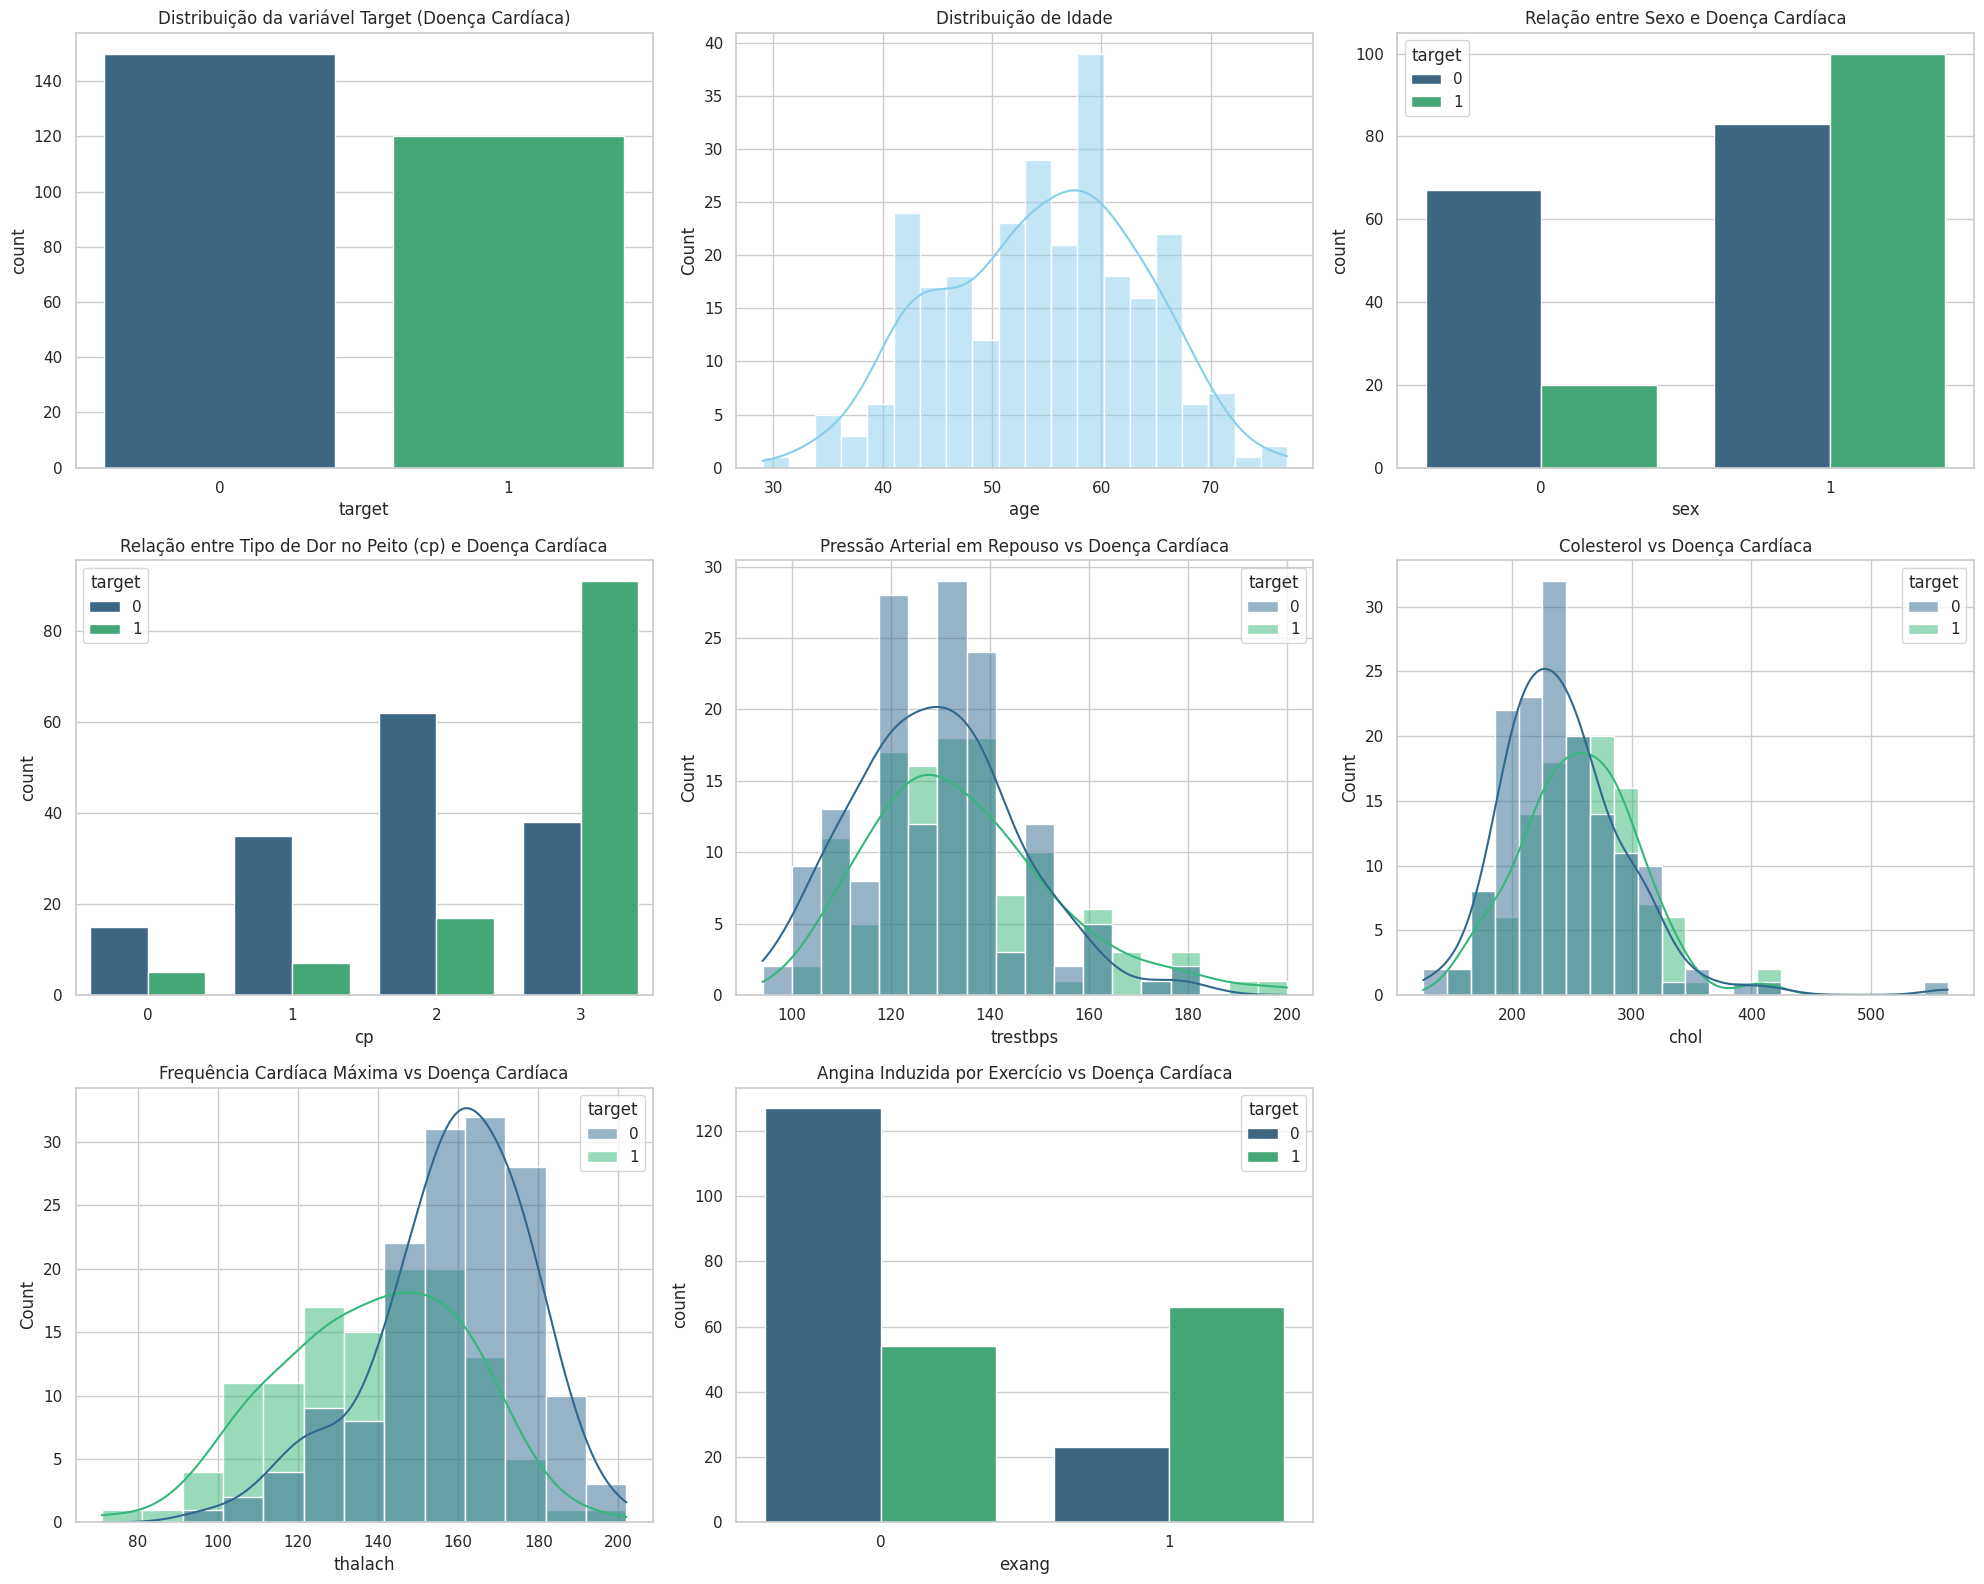

In [63]:
# Função para exibir gráficos de distribuição e relações
def plot_distribuicao(df):
    # Ajuste de estilo para visualizações
    sns.set(style="whitegrid")

    # Configurar o tamanho da figura geral
    plt.figure(figsize=(20, 16))

    # Gráficos de análise
    # 1. Distribuição da variável target (Doença Cardíaca)
    plt.subplot(3, 3, 1)
    sns.countplot(x='target', data=df, palette="viridis")
    plt.title('Distribuição da variável Target (Doença Cardíaca)')

    # 2. Distribuição de Idade
    plt.subplot(3, 3, 2)
    sns.histplot(df['age'], bins=20, kde=True, color="skyblue")
    plt.title('Distribuição de Idade')

    # 3. Sexo vs Target
    plt.subplot(3, 3, 3)
    sns.countplot(x='sex', hue='target', data=df, palette="viridis")
    plt.title('Relação entre Sexo e Doença Cardíaca')

    # 4. Tipo de dor no peito (cp) vs Target
    plt.subplot(3, 3, 4)
    sns.countplot(x='cp', hue='target', data=df, palette="viridis")
    plt.title('Relação entre Tipo de Dor no Peito (cp) e Doença Cardíaca')

    # 5. Pressão arterial em repouso (trestbps) vs Target
    plt.subplot(3, 3, 5)
    sns.histplot(df, x="trestbps", hue="target", kde=True, palette="viridis")
    plt.title('Pressão Arterial em Repouso vs Doença Cardíaca')

    # 6. Colesterol (chol) vs Target
    plt.subplot(3, 3, 6)
    sns.histplot(df, x="chol", hue="target", kde=True, palette="viridis")
    plt.title('Colesterol vs Doença Cardíaca')

    # 7. Frequência cardíaca máxima alcançada (thalach) vs Target
    plt.subplot(3, 3, 7)
    sns.histplot(df, x="thalach", hue="target", kde=True, palette="viridis")
    plt.title('Frequência Cardíaca Máxima vs Doença Cardíaca')

    # 8. Angina induzida por exercício (exang) vs Target
    plt.subplot(3, 3, 8)
    sns.countplot(x='exang', hue='target', data=df, palette="viridis")
    plt.title('Angina Induzida por Exercício vs Doença Cardíaca')

    # Ajustar o layout para evitar sobreposição
    plt.tight_layout()
    plt.show()

# Chamar a função para exibir os gráficos
plot_distribuicao(df_registro)


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

Acurácia do modelo: 0.93

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.91      0.97      0.94        33
           1       0.95      0.86      0.90        21

    accuracy                           0.93        54
   macro avg       0.93      0.91      0.92        54
weighted avg       0.93      0.93      0.93        54


Matriz de Confusão:
[[32  1]
 [ 3 18]]


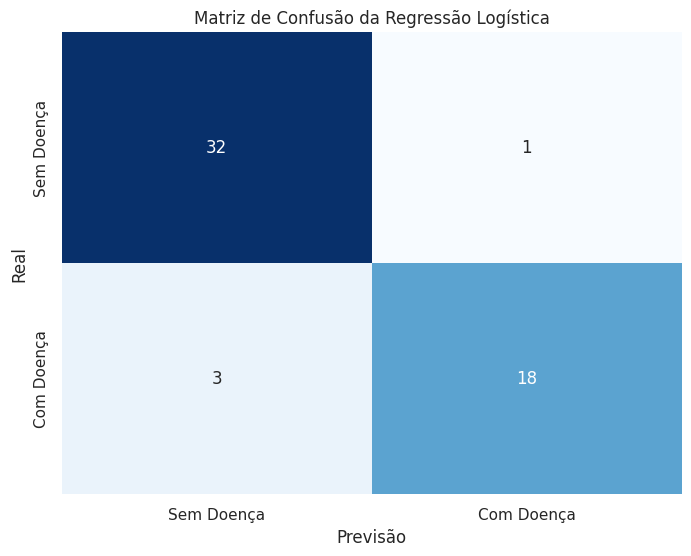

In [68]:
# 1. Separar as variáveis de entrada (features) e a variável alvo (target)
X = df_registro.drop('target', axis=1)  # Dados dos pacientes
y = df_registro['target']  # Indica se tem doença cardíaca (0 = não, 1 = sim)


# 2. Dividir os dados em treino e teste (80% treino / 20% teste)
from sklearn.model_selection import train_test_split

X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# 3. Criar e treinar o modelo de Regressão Logística
from sklearn.linear_model import LogisticRegression

modelo = LogisticRegression(max_iter=1000, random_state=42)
modelo.fit(X_treino, y_treino)


# 4. Fazer previsões com os dados de teste
y_previsto = modelo.predict(X_teste)


# 5. Avaliar o modelo
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Acurácia (percentual de acertos)
acuracia = accuracy_score(y_teste, y_previsto)
print(f'Acurácia do modelo: {acuracia:.2f}')


# Relatório completo (precision, recall, f1-score)
print("\nRelatório de Classificação:")
print(classification_report(y_teste, y_previsto))


# Matriz de confusão (erros e acertos)
print("\nMatriz de Confusão:")
print(confusion_matrix(y_teste, y_previsto))


# Plotar a matriz de confusão
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=['Sem Doença', 'Com Doença'],
            yticklabels=['Sem Doença', 'Com Doença'])

# Títulos e rótulos para tornar o gráfico mais informativo
plt.xlabel('Previsão')
plt.ylabel('Real')
plt.title('Matriz de Confusão da Regressão Logística')
plt.show()

## Avaliação do Modelo

O modelo apresentou uma acurácia de 93%, indicando alto desempenho geral.

A métrica de precisão (precision) mostrou que o modelo é confiável ao prever casos positivos, com 95% de acerto para pacientes com doença cardíaca.

No entanto, o recall para a classe positiva foi de 86%, indicando que o modelo ainda deixa de identificar alguns casos reais de doença.

Isso sugere que, embora o modelo seja preciso, há espaço para melhoria na detecção completa dos casos positivos, o que é especialmente importante em contextos médicos.


A matriz de confusão permite identificar os tipos de erro cometidos pelo modelo, mostrando onde ele acerta e onde apresenta dificuldades.

## Justificativa da Escolha do Limiar Ajustado

Na análise de modelos para predição de doenças cardíacas, a sensibilidade (recall) para identificar pacientes doentes é crucial. Uma falha na detecção de um paciente que já possui a doença pode ter consequências graves. Por isso, optei por ajustar o limiar de decisão de 0,5 para 0,3. Essa mudança foi feita de forma intencional, priorizando a identificação de todos os casos de doença, mesmo que isso leve a um aumento nos falsos positivos.

Em contexto clínico, a prioridade é não deixar nenhum caso de risco passar despercebido. Ao ajustar o limiar, conseguimos um recall de 0,90, ou seja, identificamos 90% dos pacientes doentes. Embora a precisão tenha caído um pouco (para 0,76), o F1-score se manteve em um bom equilíbrio, refletindo a necessidade de garantir que nenhum caso grave seja perdido. Dessa forma, a decisão pelo recall mais alto foi uma escolha alinhada à ética médica, priorizando a detecção de todos os pacientes que precisam de atenção.



Acurácia do modelo com limiar ajustado: 0.85

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.93      0.82      0.87        33
           1       0.76      0.90      0.83        21

    accuracy                           0.85        54
   macro avg       0.85      0.86      0.85        54
weighted avg       0.86      0.85      0.85        54


Matriz de Confusão:
[[27  6]
 [ 2 19]]
AUC-PR: 0.951


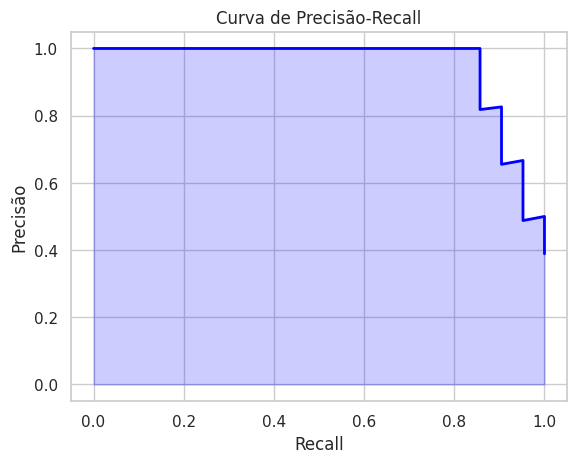

In [76]:
from sklearn.metrics import precision_recall_curve, auc
# Obter as probabilidades preditas
y_prob = modelo.predict_proba(X_teste)[:, 1]  # Probabilidade da classe 1

# Aplicar o limiar de decisão
limiar = 0.3
y_previsto = (y_prob >= limiar).astype(int)

# Avaliar o modelo com o novo limiar
accuracy = accuracy_score(y_teste, y_previsto)
print(f'Acurácia do modelo com limiar ajustado: {accuracy:.2f}')

print("\nRelatório de Classificação:")
print(classification_report(y_teste, y_previsto))

print("\nMatriz de Confusão:")
print(confusion_matrix(y_teste, y_previsto))



# Obter as probabilidades da classe 1
y_prob = modelo.predict_proba(X_teste)[:, 1]

# Calcular a curva de precisão-recall
precision, recall, thresholds = precision_recall_curve(y_teste, y_prob)

# Calcular a AUC-PR
auc_pr = auc(recall, precision)

print(f'AUC-PR: {auc_pr:.3f}')

# Plotar a curva de Precisão e Recall
plt.figure()
plt.plot(recall, precision, color='blue', lw=2)
plt.fill_between(recall, precision, alpha=0.2, color='blue')
plt.xlabel('Recall')
plt.ylabel('Precisão')
plt.title('Curva de Precisão-Recall')
plt.grid(True)
plt.show()

## Análise da Curva de Precisão e Recall (AUC-PR)

A curva de precisão e recall (PR) é uma ferramenta essencial em cenários com classes desbalanceadas. Diferente da acurácia, ela mostra o equilíbrio entre a capacidade do modelo de encontrar os positivos (recall) e o quão confiável ele é ao classificar (precisão).

No nosso modelo, a curva azul mostra que, à medida que ajustamos o limiar de decisão, o recall aumenta, ou seja, o modelo detecta mais casos de doentes, enquanto a precisão se mantém alta. O valor de AUC-PR, que é 0,95, indica que o modelo separa muito bem as classes: ele acerta a maioria dos doentes sem perder muitos saudáveis.

Essa curva, portanto, confirma que o modelo é robusto na identificação de casos positivos, o que é fundamental em um contexto clínico, onde a detecção precoce é crucial.